<a href="https://colab.research.google.com/github/i86453966-create/car/blob/main/Copy_of_car_pricing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/alexeygrigorev/mlbookcamp-code

Cloning into 'mlbookcamp-code'...
remote: Enumerating objects: 4489, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 4489 (delta 45), reused 33 (delta 33), pack-reused 4434 (from 1)
Receiving objects: 100% (4489/4489), 9.03 MiB | 16.73 MiB/s, done.
Resolving deltas: 100% (2720/2720), done.


In [ ]:
import pandas as pd
df=pd.read_csv('mlbookcamp-code/chapter-02-car-price/data.csv')

In [ ]:
df.shape

(11914, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

In [ ]:
df.head(1)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135


In [ ]:
df['Driven_Wheels'].value_counts()

,count
Driven_Wheels,
front wheel drive,4787
rear wheel drive,3371
all wheel drive,2353
four wheel drive,1403


In [ ]:
df=df.drop(['Model','Market Category'],axis=1)

In [ ]:
df.head()

,Make,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135
1,BMW,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650
2,BMW,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350
3,BMW,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450
4,BMW,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500


In [ ]:
df.columns=df.columns.str.lower().str.replace(' ','_')

In [ ]:
df.head()

,make,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135
1,BMW,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650
2,BMW,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350
3,BMW,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450
4,BMW,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500


In [ ]:
df=df.rename(columns={"msrp":"price"})

In [ ]:
df['price'].value_counts()

,count
price,
2000,1036
29995,19
25995,19
27995,16
20995,16
...,...
26115,1
27705,1
26610,1


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='price', ylabel='Count'>

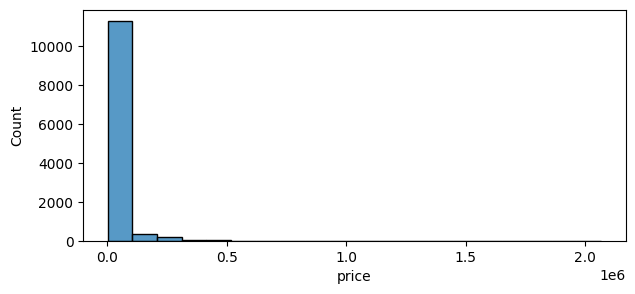

In [ ]:
plt.figure(figsize=(7,3))
sns.histplot(df['price'],bins=20)

In [ ]:
import numpy as np
df['price']=np.log1p(df.price)

In [ ]:
df['price'].value_counts()

,count
price,
7.601402,1036
10.308819,19
10.165698,19
10.239817,16
9.952087,16
...,...
10.170303,1
10.229404,1
10.189080,1


<Axes: xlabel='price', ylabel='Count'>

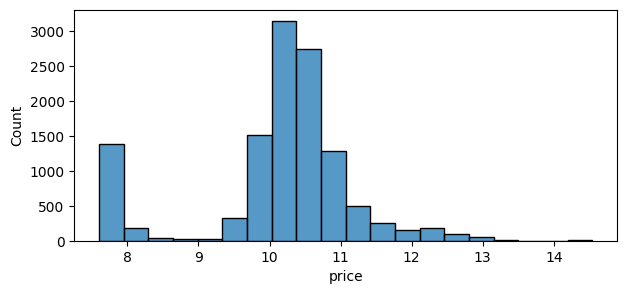

In [ ]:
plt.figure(figsize=(7,3))
sns.histplot(df['price'],bins=20)

In [ ]:
df['engine_fuel_type']=df['engine_fuel_type'].fillna(df['engine_fuel_type'].mode()[0])

In [ ]:
df.isnull().sum()

,0
make,0
year,0
engine_fuel_type,0
engine_hp,69
engine_cylinders,30
transmission_type,0
driven_wheels,0
number_of_doors,6
vehicle_size,0
vehicle_style,0


In [ ]:
df['engine_hp']=df['engine_hp'].fillna(df['engine_hp'].mean())

In [ ]:
df['engine_cylinders']=df['engine_cylinders'].fillna(df['engine_cylinders'].mean())

In [ ]:
df['number_of_doors']=df['number_of_doors'].fillna(df['number_of_doors'].mean())

In [ ]:
df.isnull().sum()

,0
make,0
year,0
engine_fuel_type,0
engine_hp,0
engine_cylinders,0
transmission_type,0
driven_wheels,0
number_of_doors,0
vehicle_size,0
vehicle_style,0


In [ ]:
df=pd.get_dummies(df,columns=['vehicle_style','make','vehicle_size','driven_wheels','transmission_type','engine_fuel_type'])

In [ ]:
df.head()

,year,engine_hp,engine_cylinders,number_of_doors,highway_mpg,city_mpg,popularity,price,vehicle_style_2dr Hatchback,vehicle_style_2dr SUV,...,engine_fuel_type_diesel,engine_fuel_type_electric,engine_fuel_type_flex-fuel (premium unleaded recommended/E85),engine_fuel_type_flex-fuel (premium unleaded required/E85),engine_fuel_type_flex-fuel (unleaded/E85),engine_fuel_type_flex-fuel (unleaded/natural gas),engine_fuel_type_natural gas,engine_fuel_type_premium unleaded (recommended),engine_fuel_type_premium unleaded (required),engine_fuel_type_regular unleaded
0,2011,335.0,6.0,2.0,26,19,3916,10.739349,False,False,...,False,False,False,False,False,False,False,False,True,False
1,2011,300.0,6.0,2.0,28,19,3916,10.612779,False,False,...,False,False,False,False,False,False,False,False,True,False
2,2011,300.0,6.0,2.0,28,20,3916,10.500977,False,False,...,False,False,False,False,False,False,False,False,True,False
3,2011,230.0,6.0,2.0,28,18,3916,10.290483,False,False,...,False,False,False,False,False,False,False,False,True,False
4,2011,230.0,6.0,2.0,28,18,3916,10.448744,False,False,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
x=df.drop(['price'],axis=1)
y=df['price']

In [ ]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test =train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
results=model.predict(x_test)

In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test,results)


0.8634005554724111

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(y_test,results,)
print(np.sqrt(mse))

0.4156079152840394


In [ ]:
from sklearn.tree import DecisionTreeRegressor
model2=DecisionTreeRegressor()
model2.fit(x_train,y_train)
result2=model2.predict(x_test)
print(r2_score(y_test,result2))
mse2=mean_squared_error(y_test,result2)
print(np.sqrt(mse2))

0.9902844461693934
0.11083913419048558


In [ ]:
from sklearn.ensemble import RandomForestRegressor
model3=RandomForestRegressor(random_state=42)
model3.fit(x_train,y_train)
result3=model3.predict(x_test)
print(r2_score(y_test,result3))
mse3=mean_squared_error(y_test,result3)
print(np.sqrt(mse3))

0.9919870328374858
0.1006597911466007
